We are experimenting to see whether we can infer significant information about the signatures from noisy samples (ie samples containing two cell types in known proportions but such that you do not know which reads belong to which cell type).

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from itertools import product
import pandas as pd
from tqdm.notebook import tqdm

## Functions

In [2]:
# EM construction of generalized soft labels
def em_soft_labels(
    signature_counts_per_sample,
    ctype_prop_per_sample,
    max_iterations=10,
    delta=None,
    verbose=False,
):
    """
    WARNING: this is a very naive implementation of EM for demonstration purposes only.
    It is not optimized for speed or memory efficiency, and should not be used for large datasets without further optimization.

    Args:
        signature_counts_per_sample: (n_samples, n_signatures)
        ctype_prop_per_sample: (n_samples, n_ctypes)
        max_iterations: maximum number of EM iterations
        delta: convergence threshold (optional)
        verbose: whether to print convergence information
    """
    # create an individual read for each signature
    n_samples, n_signatures = signature_counts_per_sample.shape
    _, n_ctypes = ctype_prop_per_sample.shape
    n_reads = signature_counts_per_sample.sum()

    sig_prob_per_ctype = np.zeros((n_ctypes, n_signatures))  # (n_ctypes, n_signatures)
    sig_prob_per_ctype_history = []

    # assign each read to a signature, and initialize its ctype probabilities
    ctype_prob_per_read = np.zeros((n_reads, n_ctypes))
    signature_index_per_read = np.zeros(n_reads, dtype=int)
    sample_index_per_read = np.zeros(n_reads, dtype=int)
    read_idx = 0
    for i in range(n_samples):
        for s in range(n_signatures):
            count = signature_counts_per_sample[i, s]
            signature_index_per_read[read_idx : read_idx + count] = s
            sample_index_per_read[read_idx : read_idx + count] = i
            # ctype_prob_per_read[read_idx : read_idx + count] = ctype_prop_per_sample[i]
            ctype_prob_per_read[read_idx : read_idx + count] = (
                np.ones(n_ctypes) / n_ctypes
            )
            read_idx += count

    # compute pseudo counts of reads per signature and ctype
    pseudo_counts_of_sig_per_ctype = np.zeros((n_ctypes, n_signatures))
    for s in range(n_signatures):
        for c in range(n_ctypes):
            pseudo_counts_of_sig_per_ctype[c, s] = ctype_prob_per_read[
                signature_index_per_read == s, c
            ].sum()

    for iteration in range(max_iterations):
        # M-step: update sig_prob_per_ctype
        sig_prob_per_ctype = (
            pseudo_counts_of_sig_per_ctype
            / pseudo_counts_of_sig_per_ctype.sum(axis=1, keepdims=True)
        )
        sig_prob_per_ctype_history.append(sig_prob_per_ctype.copy())

        # check for convergence
        if delta is not None and iteration > 0:
            change = np.abs(sig_prob_per_ctype - sig_prob_per_ctype_history[-2]).max()
            if change < delta:
                if verbose:
                    print(
                        f"Converged at iteration {iteration} with change {change:.6f}"
                    )
                break

        # E-step: update ctype_prob_per_read
        for r in range(n_reads):
            s = signature_index_per_read[r]
            i = sample_index_per_read[r]
            ctype_prob_per_read[r] = (
                ctype_prop_per_sample[i, :] * sig_prob_per_ctype[:, s]
            )
            ctype_prob_per_read[r] /= ctype_prob_per_read[r].sum()

        # recompute pseudo counts of reads per signature and ctype
        pseudo_counts_of_sig_per_ctype = np.zeros((n_ctypes, n_signatures))
        for s in range(n_signatures):
            for c in range(n_ctypes):
                pseudo_counts_of_sig_per_ctype[c, s] = ctype_prob_per_read[
                    signature_index_per_read == s, c
                ].sum()

    return sig_prob_per_ctype, np.array(sig_prob_per_ctype_history)

In [3]:
def least_square_labeler(ctype_prop_per_sample, sig_prop_per_sample):
    """
    Args:
        ctype_prop_per_sample: (n_samples, n_ctypes)
        sig_prop_per_sample: (n_samples, n_signatures)
    Returns:
        ls_sig_prob_per_ctype: (n_ctypes, n_signatures) (P(signature | ctype))
    """
    n_samples, n_ctypes = ctype_prop_per_sample.shape
    _, n_signatures = sig_prop_per_sample.shape

    # least squares
    F = cp.Variable((n_ctypes, n_signatures), nonneg=True)
    objective = cp.Minimize(
        cp.sum_squares(ctype_prop_per_sample @ F - sig_prop_per_sample)
    )
    constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
    problem = cp.Problem(objective, constraints)
    problem.solve()

    ls_sig_prob_per_ctype = F.value  # (n_ctypes, n_signatures) (P(signature | ctype))
    return ls_sig_prob_per_ctype

In [4]:
def nrmse(y_true, y_pred):
    """
    It is expected that all rows of y_true and y_pred sum to 1, and that they have the same shape.
    """
    assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"
    assert y_true.ndim == 2, "y_true and y_pred must be 2D arrays"
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # the wors possible prediction is the one that predicts 1 for the class
    # with the lowest probability in y_true for each sample, and 0 for all other classes. This is equivalent to predicting the argmin of y_true for each sample.
    worst_possible_prediction = np.zeros_like(y_true)
    worst_possible_prediction[np.arange(y_true.shape[0]), y_true.argmin(axis=1)] = 1
    worst_possible_rmse = np.sqrt(np.mean((y_true - worst_possible_prediction) ** 2))
    nrmse = rmse / worst_possible_rmse
    return nrmse

In [5]:
np.random.rand(8, 3).min(axis=1).shape

(8,)

## Playground: no pooling of counts between signatures

We need to model the following things:
- at least three samples
- two cell types (0: healthy and 1: tumor)
- a single region
- at least three signatures (reads)

In [6]:
N_SAMPLES = 3
N_CTYPES = 2
N_SIGNATURES = 3
samples_ctype_proportions = np.array(
    [
        [0.9, 0.1],
        [0.8, 0.2],
        [0.7, 0.3],
    ]
)  # (n_samples, n_ctypes)
samples_read_counts = np.array([30, 10, 10])
signatures = np.array([[0, 0, 0, 0], [0, 0, 1, 1], [1, 1, 1, 1]])
signatures_prop_per_ctype = np.array(
    [[0.0, 0.0, 1.0], [0.5, 0.5, 0.0]]
)  # (n_ctypes, n_signatures)
print("True P(signature | ctype):")
print(signatures_prop_per_ctype)

# sample the signatures contents for each sample
ctype_counts_per_sample = [
    np.random.multinomial(samples_read_counts[i], samples_ctype_proportions[i])
    for i in range(N_SAMPLES)
]
ctype_counts_per_sample = np.array(ctype_counts_per_sample)  # (n_samples, n_ctypes)
ctype_counts = ctype_counts_per_sample.sum(axis=0)  # (n_ctypes,)
ctype_proportions = ctype_counts / ctype_counts.sum()  # (n_ctypes,)

signature_counts_per_sample = (
    ctype_counts_per_sample @ signatures_prop_per_ctype
).astype(
    int
)  # (n_samples, n_signatures)
signature_proportions_per_sample = (
    signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)
)

# compute P(ctype | signature) from true proportions using Bayes' theorem
ctype_prop_per_signature = np.zeros((N_SIGNATURES, N_CTYPES), dtype=float)
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        ctype_prop_per_signature[j, c] = (
            signatures_prop_per_ctype[c, j] * ctype_proportions[c]
        )
    ctype_prop_per_signature[j] /= ctype_prop_per_signature[j].sum()
print("P(ctype | signature) from true proportions:")
print(ctype_prop_per_signature)  # (n_signatures, n_ctypes)

True P(signature | ctype):
[[0.  0.  1. ]
 [0.5 0.5 0. ]]
P(ctype | signature) from true proportions:
[[0. 1.]
 [0. 1.]
 [1. 0.]]


In [7]:
# naive soft label construction
# for each signature, we compute a weighted average of the sample ctype proportions
pseudo_global_counts_per_ctype = (
    signature_counts_per_sample.sum(axis=0) @ samples_ctype_proportions
)
naive_soft_labels = np.zeros((N_SIGNATURES, N_CTYPES))
for i in range(N_SIGNATURES):
    pseudo_counts = np.zeros(N_CTYPES)
    for j in range(N_SAMPLES):
        pseudo_counts += (
            signature_counts_per_sample[j, i] * samples_ctype_proportions[j]
        )
    normalized_pseudo_counts = pseudo_counts / pseudo_global_counts_per_ctype
    naive_soft_labels[i] = normalized_pseudo_counts / normalized_pseudo_counts.sum()
print("Naive soft labels (P(ctype | signature)):")
print(naive_soft_labels.round(4))

Naive soft labels (P(ctype | signature)):
[[0.6102 0.3898]
 [0.6102 0.3898]
 [0.6852 0.3148]]


In [8]:
em_sig_prob_per_ctype, em_sig_prob_per_ctype_history = em_soft_labels(
    signature_counts_per_sample,
    samples_ctype_proportions,
    max_iterations=1000,
    delta=1e-3,
)
print("P(signature | ctype) from EM:")
print(em_sig_prob_per_ctype.round(2))
# compute P(ctype | signature) using Bayes' theorem
em_soft_labels_per_signature = np.zeros((N_SIGNATURES, N_CTYPES))
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        em_soft_labels_per_signature[j, c] = (
            em_sig_prob_per_ctype[c, j] * ctype_proportions[c]
        )
    em_soft_labels_per_signature[j] /= em_soft_labels_per_signature[j].sum()
print("P(ctype | signature) from EM:")
print(em_soft_labels_per_signature.round(4))

P(signature | ctype) from EM:
[[0.   0.   1.  ]
 [0.38 0.38 0.23]]
P(ctype | signature) from EM:
[[0.0244 0.9756]
 [0.0244 0.9756]
 [0.9578 0.0422]]


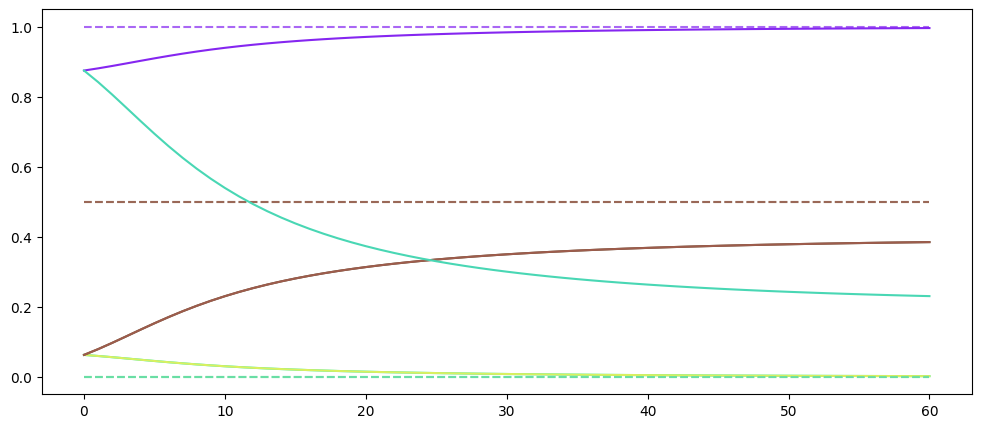

In [9]:
# plot EM convergence
length_of_history = len(em_sig_prob_per_ctype_history)
plt.figure(figsize=(12, 5))
for c in range(N_CTYPES):
    for s in range(N_SIGNATURES):
        # sample random color for each (c,s)
        color = np.random.rand(
            3,
        )
        plt.plot(
            [sig_prob[c, s] for sig_prob in em_sig_prob_per_ctype_history],
            label=f"EM P(signature {s} | ctype {c})",
            color=color,
        )
        plt.hlines(
            signatures_prop_per_ctype[c, s],
            0,
            length_of_history - 1,
            colors=color,
            linestyles="dashed",
            alpha=0.7,
            label=f"True P(signature {s} | ctype {c})" if c == 0 else None,
        )

plt.show()

In [10]:
ls_sig_prob_per_ctype = least_square_labeler(
    samples_ctype_proportions, signature_proportions_per_sample
)
print("P(signature | ctype) from least squares:")
print(ls_sig_prob_per_ctype.round(2))

# compute P(ctype | signature) using Bayes' theorem
ls_soft_labels_per_signature = np.zeros((N_SIGNATURES, N_CTYPES))
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        ls_soft_labels_per_signature[j, c] = (
            ls_sig_prob_per_ctype[c, j] * ctype_proportions[c]
        )
    ls_soft_labels_per_signature[j] /= ls_soft_labels_per_signature[j].sum()
print("P(ctype | signature) from least squares:")
print(ls_soft_labels_per_signature.round(4))

P(signature | ctype) from least squares:
[[0.01 0.01 0.99]
 [0.39 0.39 0.22]]
P(ctype | signature) from least squares:
[[0.0661 0.9339]
 [0.0661 0.9339]
 [0.9588 0.0412]]


The least square imputation of ctypes per signature is highly dependent on the number of samples.

In [11]:
def compute_mse_per_sample_size(sample_size=1000):
    # sample the signatures contents for each sample
    ctype_counts_per_sample = np.array(
        [
            np.random.multinomial(sample_size, samples_ctype_proportions[i])
            for i in range(N_SAMPLES)
        ]
    )
    signature_counts_per_sample = (
        ctype_counts_per_sample @ signatures_prop_per_ctype
    ).astype(int)
    signature_proportions_per_sample = (
        signature_counts_per_sample
        / signature_counts_per_sample.sum(axis=1, keepdims=True)
    )

    # least squares
    F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
    objective = cp.Minimize(
        cp.sum_squares(samples_ctype_proportions @ F - signature_proportions_per_sample)
    )
    constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
    problem = cp.Problem(objective, constraints)
    problem.solve()
    F_solution = F.value

    mse = np.mean((F_solution - signatures_prop_per_ctype) ** 2)
    return mse

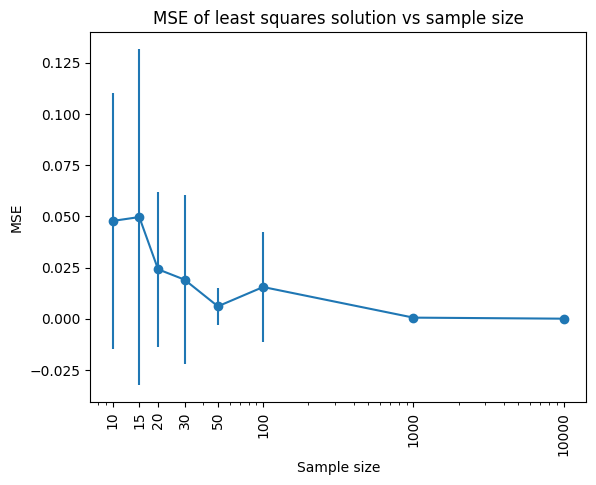

In [12]:
# plot mse per sample size
sample_sizes = [10, 15, 20, 30, 50, 100, 1000, 10000]
mse_means = []
mse_stds = []
for sample_size in sample_sizes:
    tmp_mse = []
    for _ in range(20):
        tmp_mse.append(compute_mse_per_sample_size(sample_size))
    mse_means.append(np.mean(tmp_mse))
    mse_stds.append(np.std(tmp_mse))

plt.errorbar(sample_sizes, mse_means, yerr=mse_stds, fmt="-o")
plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("MSE")
plt.xticks(sample_sizes, labels=sample_sizes, rotation=90)
plt.title("MSE of least squares solution vs sample size")
plt.show()

## Experiment 1: categorical signatures (no pooling), known ctype proportions

Assumptions:
- the signatures are categorical (ie no underlying model, nor pooling of counts between signatures).
- the ctype proportions in each sample are known.

The parameters of the experiment are as follows:
- the number of signatures (N_SIGNATURES)
- the number of samples (N_SAMPLES)
- the number of cell types (N_CTYPES)
- the ctype proportions in each sample
- the read counts per sample 
- the signature probabilities per ctype

we need N_SAMPLES > N_CTYPES

Given the high number of parameters, we will fix the way some parameters are generated:
- the ctype proportions in each sample will be generated by sampling from a Dirichlet distribution (but each sample will have a dominant cell type)
- the sig prop per ctype will be generated by sampling from a Dirichlet distribution (but each ctype will have a dominant signature)
- the number of reads per sample will increase linearly from N_READS_PER_SAMPLE_MIN to N_READS_PER_SAMPLE_MAX

In [13]:
def experiment1(
    n_signatures,
    n_ctypes,
    n_samples,
    n_reads_per_sample_min,
    n_reads_per_sample_max,
    ctype_prop_per_sample_smoothness,
    sig_prop_per_ctype_smoothness,
):

    ## Parameters of the experiment derived from the arguments
    n_reads_per_sample = np.linspace(
        n_reads_per_sample_min, n_reads_per_sample_max, n_samples, dtype=int
    )
    # select a dominant ctype for each sample, ensuring that all ctypes are represented at least once
    dominant_ctype_per_sample = np.concatenate(
        [
            np.arange(n_ctypes),
            np.random.choice(n_ctypes, size=n_samples - n_ctypes, replace=True),
        ]
    )
    np.random.shuffle(dominant_ctype_per_sample)
    ctype_prop_per_sample = np.array(
        [
            np.random.dirichlet(
                alpha=np.array(
                    [
                        (
                            0.6
                            if c == dominant_ctype_per_sample[i]
                            else 0.4 / (n_ctypes - 1)
                        )
                        for c in range(n_ctypes)
                    ]
                )
                * ctype_prop_per_sample_smoothness
            )
            for i in range(n_samples)
        ]
    )
    # Sample the signature proportions for each ctype, with a dominant signature for each ctype
    dominant_signature_per_ctype = np.random.choice(
        n_signatures, size=n_ctypes, replace=True
    )
    signature_prop_per_ctype = np.array(
        [
            np.random.dirichlet(
                alpha=np.array(
                    [
                        (
                            0.6
                            if s == dominant_signature_per_ctype[c]
                            else 0.4 / (n_signatures - 1)
                        )
                        for s in range(n_signatures)
                    ]
                )
                * sig_prop_per_ctype_smoothness
            )
            for c in range(n_ctypes)
        ]
    )

    ##  Simulation: sample the signatures contents for each sample
    # First sample the ctype counts for each sample
    ctype_counts_per_sample = np.array(
        [
            np.random.multinomial(n_reads_per_sample[i], ctype_prop_per_sample[i])
            for i in range(n_samples)
        ]
    )
    global_ctype_counts = ctype_counts_per_sample.sum(axis=0)
    global_ctype_proportions = global_ctype_counts / global_ctype_counts.sum()

    # Then sample the signature counts for each sample based on the ctype counts and the signature proportions per ctype
    signature_counts_per_sample = np.zeros((n_samples, n_signatures), dtype=int)
    for i in range(n_samples):
        for c in range(n_ctypes):
            signature_counts_per_sample[i] += np.random.multinomial(
                ctype_counts_per_sample[i, c], signature_prop_per_ctype[c]
            )
    signature_proportions_per_sample = (
        signature_counts_per_sample
        / signature_counts_per_sample.sum(axis=1, keepdims=True)
    )
    return {
        "n_reads_per_sample": n_reads_per_sample,
        "dominant_ctype_per_sample": dominant_ctype_per_sample,
        "ctype_prop_per_sample": ctype_prop_per_sample,
        "dominant_signature_per_ctype": dominant_signature_per_ctype,
        "signature_prop_per_ctype": signature_prop_per_ctype,
        "ctype_counts_per_sample": ctype_counts_per_sample,
        "global_ctype_counts": global_ctype_counts,
        "global_ctype_proportions": global_ctype_proportions,
        "signature_counts_per_sample": signature_counts_per_sample,
        "signature_proportions_per_sample": signature_proportions_per_sample,
    }

In [14]:
simulated_data = experiment1(
    n_signatures=3,
    n_ctypes=3,
    n_samples=6,
    n_reads_per_sample_min=20,
    n_reads_per_sample_max=100,
    ctype_prop_per_sample_smoothness=10,
    sig_prop_per_ctype_smoothness=10,
)

print("True ctype proportions per sample:")
print(simulated_data["ctype_prop_per_sample"].round(2))
print("True signature proportions per ctype:")
print(simulated_data["signature_prop_per_ctype"].round(2))
print("Sampled ctype counts per sample:")
print(simulated_data["ctype_counts_per_sample"])
print("Global ctype proportions:")
print(simulated_data["global_ctype_proportions"].round(2))
print("Sampled signature counts per sample:")
print(simulated_data["signature_counts_per_sample"])
print("Sampled signature proportions per sample:")
print(simulated_data["signature_proportions_per_sample"].round(2))

True ctype proportions per sample:
[[0.06 0.3  0.63]
 [0.3  0.11 0.59]
 [0.06 0.06 0.88]
 [0.26 0.69 0.06]
 [0.08 0.1  0.82]
 [0.15 0.77 0.07]]
True signature proportions per ctype:
[[0.1  0.14 0.76]
 [0.05 0.85 0.1 ]
 [0.28 0.04 0.68]]
Sampled ctype counts per sample:
[[ 1  7 12]
 [11  3 22]
 [ 5  4 43]
 [13 51  4]
 [ 6 11 67]
 [15 79  6]]
Global ctype proportions:
[0.14 0.43 0.43]
Sampled signature counts per sample:
[[ 2  8 10]
 [ 7  8 21]
 [18  4 30]
 [ 4 46 18]
 [25 17 42]
 [ 6 75 19]]
Sampled signature proportions per sample:
[[0.1  0.4  0.5 ]
 [0.19 0.22 0.58]
 [0.35 0.08 0.58]
 [0.06 0.68 0.26]
 [0.3  0.2  0.5 ]
 [0.06 0.75 0.19]]


Now onto the actual algorithm evaluations.

In [15]:
em_sig_prob_per_ctype, em_sig_prob_per_ctype_history = em_soft_labels(
    simulated_data["signature_counts_per_sample"],
    simulated_data["ctype_prop_per_sample"],
    max_iterations=1000,
    delta=1e-4,
)
ls_sig_prob_per_ctype = least_square_labeler(
    simulated_data["ctype_prop_per_sample"],
    simulated_data["signature_proportions_per_sample"],
)

print("True P(signature | ctype):")
print(simulated_data["signature_prop_per_ctype"].round(2))
print(
    f"P(signature | ctype) from EM: NRMSE={nrmse(simulated_data['signature_prop_per_ctype'], em_sig_prob_per_ctype):.4f}"
)
print(em_sig_prob_per_ctype.round(2))
print(
    f"P(signature | ctype) from least squares: NRMSE={nrmse(simulated_data['signature_prop_per_ctype'], ls_sig_prob_per_ctype):.4f}"
)
print(ls_sig_prob_per_ctype.round(2))

True P(signature | ctype):
[[0.1  0.14 0.76]
 [0.05 0.85 0.1 ]
 [0.28 0.04 0.68]]
P(signature | ctype) from EM: NRMSE=0.0912
[[0.03 0.24 0.72]
 [0.04 0.91 0.05]
 [0.34 0.07 0.58]]
P(signature | ctype) from least squares: NRMSE=0.0770
[[0.1  0.19 0.71]
 [0.   0.93 0.07]
 [0.32 0.09 0.6 ]]


In [37]:
# systematic exploration of the parameter space
n_signatures_grid = [3, 5, 7, 10]
n_ctypes_grid = [2, 4, 6]
n_samples_grid = [3, 5, 7, 15]
n_reads_per_sample_min = 6
n_reads_per_sample_max = 30
ctype_prop_per_sample_smoothness_grid = [1, 10]
sig_prop_per_ctype_smoothness_grid = [1, 10]
N_SIMULATIONS = 20

results_records = []
skipped_combinations = []

expected_total_runs = (
    len(n_signatures_grid)
    * len(n_ctypes_grid)
    * len(n_samples_grid)
    * len(ctype_prop_per_sample_smoothness_grid)
    * len(sig_prop_per_ctype_smoothness_grid)
)
for (
    n_signatures,
    n_ctypes,
    n_samples,
    ctype_smoothness,
    sig_smoothness,
) in tqdm(
    product(
        n_signatures_grid,
        n_ctypes_grid,
        n_samples_grid,
        ctype_prop_per_sample_smoothness_grid,
        sig_prop_per_ctype_smoothness_grid,
    ),
    total=expected_total_runs,
    desc="Parameter combinations",
):
    # experiment1 requires all ctypes to be represented at least once
    if n_samples < n_ctypes:
        skipped_combinations.append(
            {
                "n_signatures": n_signatures,
                "n_ctypes": n_ctypes,
                "n_samples": n_samples,
                "ctype_prop_per_sample_smoothness": ctype_smoothness,
                "sig_prop_per_ctype_smoothness": sig_smoothness,
                "reason": "n_samples < n_ctypes",
            }
        )
        continue

    for simulation_id in range(N_SIMULATIONS):
        simulated_data = experiment1(
            n_signatures=n_signatures,
            n_ctypes=n_ctypes,
            n_samples=n_samples,
            n_reads_per_sample_min=n_reads_per_sample_min,
            n_reads_per_sample_max=n_reads_per_sample_max,
            ctype_prop_per_sample_smoothness=ctype_smoothness,
            sig_prop_per_ctype_smoothness=sig_smoothness,
        )

        true_sig_prop_per_ctype = simulated_data["signature_prop_per_ctype"]

        em_sig_prob_per_ctype, _ = em_soft_labels(
            simulated_data["signature_counts_per_sample"],
            simulated_data["ctype_prop_per_sample"],
            max_iterations=1000,
            delta=1e-4,
        )

        ls_sig_prob_per_ctype = least_square_labeler(
            simulated_data["ctype_prop_per_sample"],
            simulated_data["signature_proportions_per_sample"],
        )

        results_records.append(
            {
                "n_signatures": n_signatures,
                "n_ctypes": n_ctypes,
                "n_samples": n_samples,
                "n_reads_per_sample_min": n_reads_per_sample_min,
                "n_reads_per_sample_max": n_reads_per_sample_max,
                "ctype_prop_per_sample_smoothness": ctype_smoothness,
                "sig_prop_per_ctype_smoothness": sig_smoothness,
                "simulation_id": simulation_id,
                "em_nrmse": float(
                    nrmse(true_sig_prop_per_ctype, em_sig_prob_per_ctype)
                ),
                "ls_nrmse": float(
                    nrmse(true_sig_prop_per_ctype, ls_sig_prob_per_ctype)
                ),
            }
        )

# Row-level results: one row per simulation, easy filtering/querying
results_df = pd.DataFrame.from_records(results_records)

# Optional MultiIndex view for convenient slicing by fixed parameter values
multiindex_cols = [
    "n_signatures",
    "n_ctypes",
    "n_samples",
    "n_reads_per_sample_min",
    "n_reads_per_sample_max",
    "ctype_prop_per_sample_smoothness",
    "sig_prop_per_ctype_smoothness",
    "simulation_id",
]
results_df = results_df.set_index(multiindex_cols).sort_index()


print(f"Skipped combinations: {len(skipped_combinations)}")
print(f"Total simulation runs stored: {len(results_df)}")

# Example slicing:
# 1) fix one parameter
# results_df.xs(5, level="n_signatures")
# 2) fix several parameters
# results_df.xs((5, 4), level=("n_signatures", "n_ctypes"))
# 3) retrieve the 10-run arrays for one exact parameter combination
# results_agg.loc[(5, 4, 7, 6, 30, 10, 10)]

Parameter combinations:   0%|          | 0/192 [00:00<?, ?it/s]

Skipped combinations: 48
Total simulation runs stored: 2880


In [40]:
grids = {
    "n_signatures": n_signatures_grid,
    "n_ctypes": n_ctypes_grid,
    "n_samples": n_samples_grid,
    "ctype_prop_per_sample_smoothness": ctype_prop_per_sample_smoothness_grid,
    "sig_prop_per_ctype_smoothness": sig_prop_per_ctype_smoothness_grid,
}

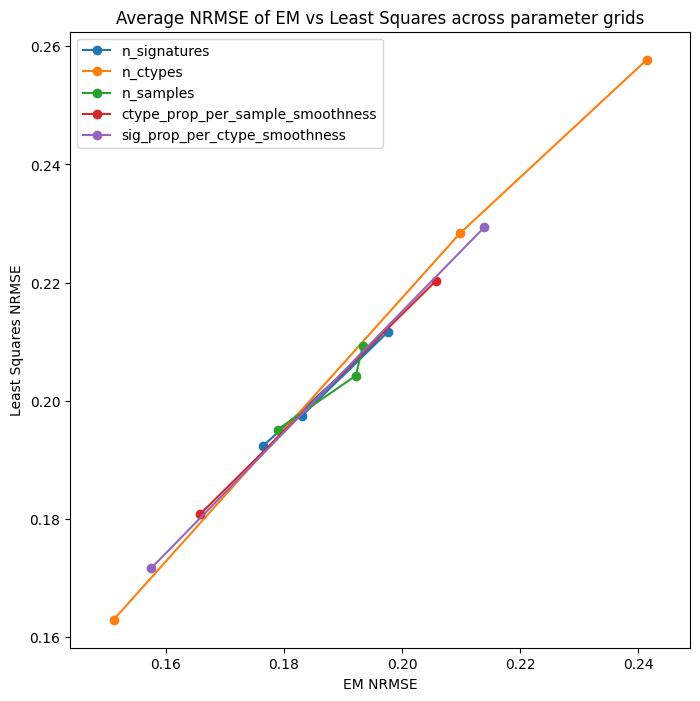

In [ ]:
# Plot LS NRMSE vs EM NRMSE for all grids
plt.figure(figsize=(8, 8))
plt.axis("equal")
for param_name, param_values in grids.items():
    em_nrmse_means = []
    ls_nrmse_means = []
    for param_value in param_values:
        subset = results_df.xs(param_value, level=param_name)
        em_nrmse_means.append(subset["em_nrmse"].mean())
        ls_nrmse_means.append(subset["ls_nrmse"].mean())
    plt.plot(em_nrmse_means, ls_nrmse_means, marker="o", label=param_name)
plt.xlabel("EM NRMSE")
plt.ylabel("Least Squares NRMSE")
plt.title("Average NRMSE of EM vs Least Squares across parameter grids")
plt.legend()
plt.show()

NRMSE: lower is better


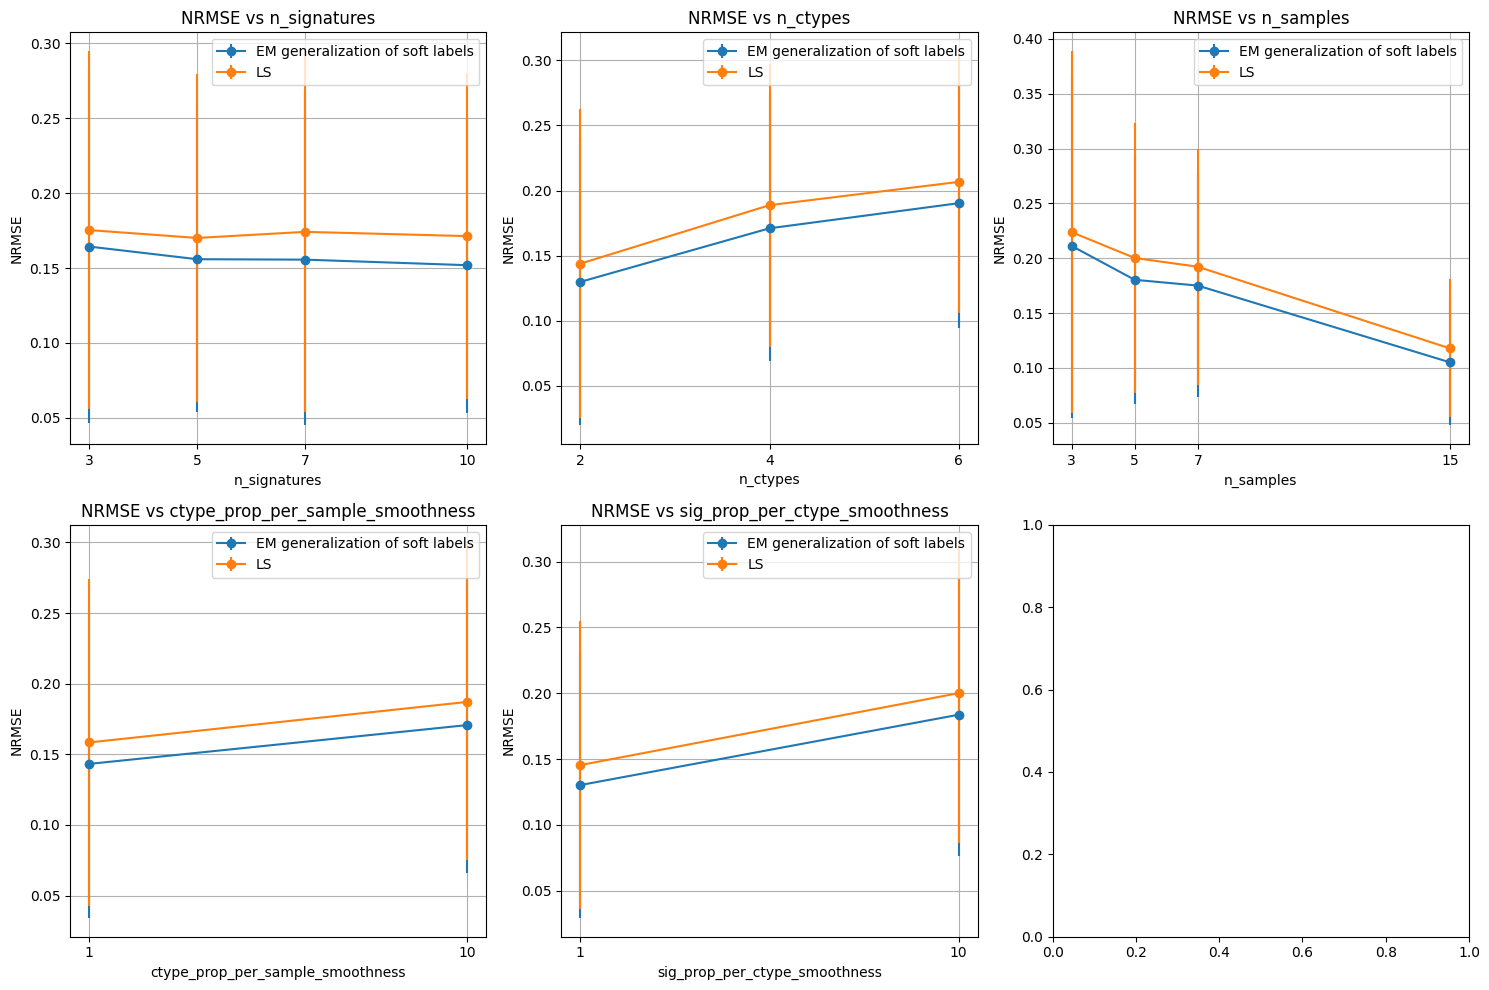

In [41]:
# plot a 2x3 grid of EM and LS NRMSE means and stds for the 5 grids
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, (param_name, param_values) in enumerate(grids.items()):
    em_nrmse_means = []
    em_nrmse_stds = []
    ls_nrmse_means = []
    ls_nrmse_stds = []
    for param_value in param_values:
        subset = results_df.xs(param_value, level=param_name)
        em_nrmse_means.append(subset["em_nrmse"].mean())
        em_nrmse_stds.append(subset["em_nrmse"].std())
        ls_nrmse_means.append(subset["ls_nrmse"].mean())
        ls_nrmse_stds.append(subset["ls_nrmse"].std())
    axes[idx].errorbar(
        param_values,
        em_nrmse_means,
        yerr=em_nrmse_stds,
        label="EM generalization of soft labels",
        marker="o",
    )
    axes[idx].errorbar(
        param_values, ls_nrmse_means, yerr=ls_nrmse_stds, label="LS", marker="o"
    )
    axes[idx].set_xlabel(param_name)
    axes[idx].grid(True)
    axes[idx].set_xticks(param_values)
    axes[idx].set_ylabel("NRMSE")
    axes[idx].set_title(f"NRMSE vs {param_name}")
    axes[idx].legend()
plt.tight_layout()
print("NRMSE: lower is better")
plt.show()

## Experiment 2: signatures modeled from methylation archetypes, trying to find a pooling method that allows to infer the correct sig prop per ctype

The goal is to see what pooling method allows best to infer the correct sig prop per ctype from the noisy samples with low counts.
In order to create a non-random structure in the signatures, we assume that the signatures are generated from methylation archetypes, and that methylation archetypes are more or less probable depending on the ctype. The generative model for a single read is as follows:
- sample a ctype according to the ctype proportions of the sample
- sample a methylation archetype according to the (hidden) methylation archetype proportions of the ctype
- sample a signature according to the per cpg methylation probabilities of the methylation archetype

In [ ]:
#

## Experiment 3: unknown ctype proportions

## Experiment X: low per sample coverage and pooling of counts

We use realistic coverage and fractions.

In [ ]:
# THIS EXPERIMENT IS DISCONTINUED FOR NOW
assert False, "End of code snippet"

In [ ]:
N_CTYPES = 2
signatures = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [1, 1, 0, 1],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)
N_SIGNATURES = signatures.shape[0]

In [ ]:
N_SAMPLES = 8
ctype_proportions_per_sample = np.array(
    [
        [0.81, 0.19],  # tumor sample
        [0.69, 0.31],  # tumor sample
        [0.54, 0.46],  # tumor sample
        [0.95, 0.05],  # normal sample
        [0.97, 0.03],  # normal sample
        [0.98, 0.02],  # normal sample
        [0.98, 0.02],  # normal sample
        [0.97, 0.03],  # normal sample
    ]
)  # (n_samples, n_ctypes)
read_counts_per_sample = np.array([4, 7, 9, 7, 10, 6, 7, 7])  # (n_samples,)
scaling = 1
read_counts_per_sample *= scaling
cancer_weight_by_unmethylated_cpg = [20, 5, 3, 2.0, 0]
dummy_proportions = [
    cancer_weight_by_unmethylated_cpg[int(sig.sum())] for sig in signatures
]
dummy_proportions = np.array(dummy_proportions)
dummy_proportions /= dummy_proportions.sum()
signature_proportions_per_ctype = np.array(
    [
        dummy_proportions[::-1],  # ctype 0 (healthy, mostly methylated)
        dummy_proportions,  # ctype 1 (tumor, mostly unmethylated)
    ]
)  # (n_ctypes, n_signatures)

In [ ]:
for i in range(5):
    total = 0
    count = 0
    for j in range(N_SIGNATURES):
        if signatures[j].sum() == i:
            total += dummy_proportions[j]
            count += 1
    print(f"Sum {i}: mean {total/count:.2f}, count {count}")

In [ ]:
np.bincount(signatures.sum(axis=1), weights=dummy_proportions)

In [ ]:
# sample the signatures contents for each sample
ctype_counts_per_sample = np.array(
    [
        np.random.multinomial(
            read_counts_per_sample[i], ctype_proportions_per_sample[i]
        )
        for i in range(N_SAMPLES)
    ]
)
signature_counts_per_sample = np.array(
    [
        np.random.multinomial(
            ctype_counts_per_sample[i, 0], signature_proportions_per_ctype[0]
        )
        + np.random.multinomial(
            ctype_counts_per_sample[i, 1], signature_proportions_per_ctype[1]
        )
        for i in range(N_SAMPLES)
    ]
)
signature_proportions_per_sample = (
    signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)
)
print(signature_counts_per_sample)

In [ ]:
# print for each sample the number of signatures having 0, 1, 2, 3, or 4 unmethylated CpGs
for i in range(N_SAMPLES):
    print(f"Sample {i}:", end=" ")
    print(
        np.bincount(
            signatures.sum(axis=1), weights=signature_counts_per_sample[i]
        ).astype(int)
    )

In [ ]:
# naive pooling: pooling counts from all signatures at a distance of 1 CpG


def signature_distance(sig1, sig2):
    return np.sum(np.abs(sig1 - sig2))


pooled_signature_counts_per_sample = np.zeros((N_SAMPLES, N_SIGNATURES), dtype=int)
for i in range(N_SAMPLES):
    for j in range(N_SIGNATURES):
        for k in range(N_SIGNATURES):
            if signature_distance(signatures[j], signatures[k]) <= 1:
                pooled_signature_counts_per_sample[i, j] += signature_counts_per_sample[
                    i, k
                ]
pooled_signature_proportions_per_sample = (
    pooled_signature_counts_per_sample
    / pooled_signature_counts_per_sample.sum(axis=1, keepdims=True)
)

In [ ]:
# print for each sample the number of signatures having 0, 1, 2, 3, or 4 unmethylated CpGs
for i in range(N_SAMPLES):
    print(f"Sample {i}:", end=" ")
    print(
        np.bincount(
            signatures.sum(axis=1), weights=pooled_signature_counts_per_sample[i]
        ).astype(int)
    )

In [ ]:
signature_counts_per_sample

In [ ]:
# least squares
F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
objective = cp.Minimize(
    cp.sum_squares(ctype_proportions_per_sample @ F - signature_proportions_per_sample)
)
constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
problem = cp.Problem(objective, constraints)
problem.solve()
F_solution = F.value
F_solution.round(2).T

In [ ]:
signature_proportions_per_ctype.round(2).T